# Sprint 2: Exploratory Data Analysis (EDA) - Project

# Contents <a id='back'></a>

* [Introduction](#intro)
* [Stage 1. Description of the project](#project_description)
    * [1.1 Information on the dataset](#dataset_info)
    * [1.2 Information on the data dictionary](#data_dict_info)
    * [1.3 Mission of the project](#project_mission)
    * [1.4 Requirement for the project](#project_mission)
* [Stage 2. Instructions for completing the project](#project_completion_instructions)
    * [2.1 Step 1](#step_1)
    * [2.2 Step 2](#step_2)
        * [2.2.1 Task A](#step_2_task_A)
        * [2.2.2 Task B](#step_2_task_B)
        * [2.2.3 Task C](#step_2_task_C)
    * [2.3 Step 3](#step_3)
        * [2.3.1 Task A](#step_3_task_A)
            * [2.3.1 Task A.1](#step_3_task_A_subtask_1)
            * [2.3.2 Task A.2](#step_3_task_A_subtask_2)
            * [2.3.3 Task A.3](#step_3_task_A_subtask_3)
            * [2.3.4 Task A.4](#step_3_task_A_subtask_4)
        * [2.3.2 Task B](#step_3_task_B)
            * [2.3.1 Task B.1](#step_3_task_B_subtask_1)
            * [2.3.2 Task B.2](#step_3_task_B_subtask_2)
            * [2.3.3 Task B.3](#step_3_task_B_subtask_3)
        * [2.3.3 Task C](#step_3_task_C)
            * [2.3.1 Task C.1](#step_3_task_C_subtask_1)
            * [2.3.1 Task C.2](#step_3_task_C_subtask_2)
            * [2.3.1 Task C.3](#step_3_task_C_subtask_3)
* [Conclusion](#conclu)

# Introduction

## Description of the project

For this project, you’ll work with data from Instacart. 

Instacart is a grocery delivery platform where customers can place a grocery order and have it delivered to them, similar to how Uber Eats and Door Dash work. This particular dataset was publicly released by Instacart in 2017 for a Kaggle competition. Although the original dataset is no longer available on the Instacart website, we’ve created CSV files that contain a modified version of that data. Download these files and use them for your project.

### Information on the dataset

The dataset we've provided for you has been modified from the original. We've reduced the size of the dataset so that your calculations run faster and we’ve introduced missing and duplicate values. We were also careful to preserve the distributions of the original data when we made our changes.

### Information on the data dictionary

There are five tables in the dataset, and you’ll need to use all of them to do your data preprocessing and EDA. Below is a data dictionary that lists the columns in each table and describes that data that hold.

* `instacart_orders.csv`: each row corresponds to one order on the Instacart app
    - `'order_id'`: ID number that uniquely identifies each order
    - `'user_id'`: ID number that uniquely identifies each customer account
    - `'order_number'`: the number of times this customer has placed an order
    -`'order_dow'`: day of the week that the order placed (which day is 0 is uncertain)
    - `'order_hour_of_day'`: hour of the day that the order was placed
    - `'days_since_prior_order'`: number of days since this customer placed their previous order

* `products.csv`: each row corresponds to a unique product that customers can buy
    - `'product_id'`: ID number that uniquely identifies each product
    - `'product_name'`: name of the product
    - `'aisle_id'`: ID number that uniquely identifies each grocery aisle category
    - `'department_id'`: ID number that uniquely identifies each grocery department category

* `order_products.csv`: each row corresponds to one item placed in an order
    - `'order_id'`: ID number that uniquely identifies each order
    - `'product_id'`: ID number that uniquely identifies each product
    - `'add_to_cart_order'`: the sequential order in which each item was placed in the cart
    - `'reordered'`: 0 if the customer has never ordered this product before, 1 if they have

* `aisles.csv`
    - `'aisle_id'`: ID number that uniquely identifies each grocery aisle category
    - `'aisle'`: name of the aisle

* `departments.csv`
    - `'department_id'`: ID number that uniquely identifies each grocery department category
    - `'department'`: name of the department

### Mission of the project

Your mission is to clean up the data and prepare a report that gives insight into the shopping habits of Instacart customers. After answering each question, write a brief explanation of your results in a markdown cell of your Jupyter notebook.

### Requirement for the project

This project will require you to make plots that communicate your results. Make sure that any plots you create have a title, labeled axes, and a legend if necessary; and include `plt.show()` at the end of each cell with a plot.

## Instructions for completing the project

### Step 1 - Opening the data files:

Open the data files (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv`, and `/datasets/order_products.csv`) and have a look at the general contents of each table. Note that the files have nonstandard formatting, so you'll need to set certain arguments in `pd.read_csv()` to read the data correctly. Take a look at the CSV files to get a sense of what those arguments should be.

Note that `order_products.csv` contains many rows of data. When a DataFrame has too many rows, `info()` will not print the non-null counts by default. If you want to to print the non-null counts, include `show_counts=True` when you call `info()`.

### Step 2 - Preprocessing the data:

- Verify and fix data types (e.g. make sure ID columns are integers)
- Identify and fill in missing values
- Identify and remove duplicate values

Be sure to explain what types of missing and duplicate values you found, how you filled or removed them, why you used those methods, and why you think these missing and duplicate values may have been present in the dataset.

## Find and remove duplicate values (and describe why you make your choices)

### `orders` data frame

In [1]:
# Import libraries

import pandas as pd


In [2]:
# Upload files

orders_df = pd.read_csv('/datasets/instacart_orders.csv', sep=';')


In [3]:
# Open '/datasets/instacart_orders.csv' data frame

print(orders_df.info(show_counts=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [4]:
# Check for duplicated orders

duplicates = orders_df.duplicated(subset='order_id', keep=False)

duplicate_orders = orders_df[duplicates]

print(duplicate_orders)


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   
164581   1112182   202304            84          3                  2   
200059   1782114   106752             1          3                  2   
204042   2125197    14050            48          3                  2   
215294   2160484   107525            16          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
242618   1021560    53767             3          3                  2   
250626    467134    63189            21          3 

In [5]:
# Check for all orders placed Wednesday at 2:00 AM

wednesday_orders = orders_df[(orders_df['order_dow'] == 3) & (orders_df['order_hour_of_day'] == 2)]
                                                
print(wednesday_orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

In [6]:
# Remove duplicate orders

df_cleaned = orders_df.drop_duplicates(subset='order_id')


In [7]:
# Double-check for duplicate rows

duplicate_rows = orders_df[orders_df.duplicated()]

print(duplicate_rows)


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

In [8]:
# Double-check for duplicate order IDs only

duplicates = orders_df[orders_df.duplicated(subset='order_id', keep=False)]

print(duplicates)


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   
164581   1112182   202304            84          3                  2   
200059   1782114   106752             1          3                  2   
204042   2125197    14050            48          3                  2   
215294   2160484   107525            16          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
242618   1021560    53767             3          3                  2   
250626    467134    63189            21          3 

### `products` data frame

In [9]:
# Open `products_df` data frame

products_df = pd.read_csv('/datasets/products.csv', sep=';') 

print(products_df.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [10]:
# Check for fully duplicate rows

fully_duplicate_rows = products_df[products_df.duplicated()]

print(fully_duplicate_rows)


Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [11]:
# Check for just duplicate product IDs

duplicates = products_df[products_df.duplicated(subset='product_id',keep=False)]


In [12]:
# Check for just duplicate product names (but first convert names to lowercase to compare better)

products_df['product_name_lower'] = products_df['product_name'].str.lower()

duplicates = products_df[products_df.duplicated('product_name_lower', keep=False)]

print(duplicates)

       product_id                                     product_name  aisle_id  \
37             38                                              NaN       100   
41             42                                  Biotin 1000 mcg        47   
71             72                                              NaN       100   
109           110                                              NaN       100   
185           186       Fresh Scent Dishwasher Detergent with Dawn        74   
...           ...                                              ...       ...   
49689       49690                    HIGH PERFORMANCE ENERGY DRINK        64   
49690       49691                    ORIGINAL PANCAKE & WAFFLE MIX       130   
49691       49692  ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR       130   
49692       49693                           SPRING WATER BODY WASH       127   
49693       49694                          BURRITO- STEAK & CHEESE        38   

       department_id                   

In [13]:
# Check for duplicate product names that aren't missing

non_missing_product_names = products_df['product_name'].dropna()

duplicates = non_missing_product_names[non_missing_product_names.duplicated()]

print(duplicates)


Series([], Name: product_name, dtype: object)


### `departments` data frame

In [14]:
# Open `departments.csv` data frame

departments_df = pd.read_csv('/datasets/departments.csv', sep=';')

print(departments_df.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


In [15]:
# Check for fully duplicate rows

fully_duplicate_rows = departments_df[departments_df.duplicated()]

print(fully_duplicate_rows)

Empty DataFrame
Columns: [department_id, department]
Index: []


In [16]:
# Double-check for any other tricky duplicates

print(departments_df.isnull().sum())

print(departments_df['department'].nunique())

department_id    0
department       0
dtype: int64
21


### `aisles` data frame

In [17]:
# Open 'aisles.csv' data frame

aisles_df = pd.read_csv('/datasets/aisles.csv', sep=';')

print(aisles_df.info(show_counts=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [18]:
# Check for fully duplicate rows

fully_duplicate_rows = aisles_df[aisles_df.duplicated()]

print(fully_duplicate_rows)


Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


In [19]:
# Double check for any other tricky duplicates

print(aisles_df.isnull().sum())

print(aisles_df['aisle'].nunique())

aisle_id    0
aisle       0
dtype: int64
134


### `order_products` data frame

In [20]:
# Open 'order_prodcts' data frame

order_products_df = pd.read_csv('/datasets/order_products.csv', sep=';')

print(order_products_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


In [21]:
# Check for fullly duplicate rows

fully_duplicate_rows = order_products_df[order_products_df.duplicated()]

print(fully_duplicate_rows)


Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [22]:
# Double-check for any other tricky duplicates

print(order_products_df.isnull().sum())

print(order_products_df['reordered'].nunique())


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64
2


## Find and remove missing values


### `products` data frame

In [23]:
# Filter to locate missing data associations

missing_product_names = products_df[products_df['product_name'].isnull()]

print(missing_product_names)


       product_id product_name  aisle_id  department_id product_name_lower
37             38          NaN       100             21                NaN
71             72          NaN       100             21                NaN
109           110          NaN       100             21                NaN
296           297          NaN       100             21                NaN
416           417          NaN       100             21                NaN
...           ...          ...       ...            ...                ...
49552       49553          NaN       100             21                NaN
49574       49575          NaN       100             21                NaN
49640       49641          NaN       100             21                NaN
49663       49664          NaN       100             21                NaN
49668       49669          NaN       100             21                NaN

[1258 rows x 5 columns]


In [24]:
# Are all of the missing product names associated with aisle ID 100?

missing_product_names = products_df[products_df['product_name'].isnull()]

associated_with_aisle_100 = missing_product_names['aisle_id'] == 100 
all_associated = associated_with_aisle_100.all()

print(all_associated)


True


In [25]:
# Are all of the missing product names associated with department ID 21?

missing_product_names = products_df[products_df['product_name'].isnull()]

associated_with_department_id_21 = missing_product_names['department_id'] == 21 
all_associated = associated_with_department_id_21.all()

print(all_associated)

True


In [26]:
# What is this aisle and department?

aisles_df = aisles_df

missing_aisle_info = missing_product_names.merge (aisles_df, on='aisle_id', how='left')

print(missing_aisle_info[['aisle_id', 'aisle']].drop_duplicates())

departments_df = departments_df

missing_department_info = missing_product_names.merge (departments_df, on='department_id', how='left')


print(missing_department_info[['department_id', 'department']].drop_duplicates())

   aisle_id    aisle
0       100  missing
   department_id department
0             21    missing


In [27]:
# Fill missing product names with 'Unknown'

products_df['product_name'].fillna('Unknown', inplace=True)

print(products_df['product_name'].isnull().sum())


0


### `orders` data frame

In [28]:
# Filter to locate missing data associations

missing_product_names = orders_df[orders_df['order_id'].isnull()]

print(missing_product_names)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


In [29]:
# Are there any missing values where it's not a customer's first order?

## Filter orders

non_first_orders = orders_df[orders_df['order_number'] > 1]

## Identify missing values

missing_in_non_first_orders = non_first_orders[non_first_orders.isnull().any(axis=1)]

## Print or analyze results

print(missing_in_non_first_orders)


Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


### `order_products` data frame

In [30]:
# Filter to locate missing data associations

missing_product_names = order_products_df[order_products_df['product_id'].isnull()]

print(missing_product_names)

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [31]:
# What are the min and max values in this column?

min_value = order_products_df['add_to_cart_order'].min()

max_value = order_products_df['add_to_cart_order'].max()

print(f"Min value: {min_value}")

print(f"Max value: {max_value}")


Min value: 1.0
Max value: 64.0


In [32]:
# Open 'order_products' data frame

order_products_df = pd.read_csv('/datasets/order_products.csv', sep=';')

print(order_products_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


In [33]:
print(order_products_df.columns)

print(order_products_df.head())

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')
   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


In [34]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'

missing_values = order_products_df[order_products_df['add_to_cart_order'].isnull()]

order_ids_with_missing_values = missing_values['order_id'].unique()


In [35]:
# Do all orders with missing values have more than 64 products?

## Identify missing values

missing_values = order_products_df.isnull().sum()

print(f"Missing values in each column:\n{missing_values}\n")


## Group and count products in order

order_counts = order_products_df.groupby('order_id')['product_id'].count()

print(f"Order counts (first 5):\n{order_counts.head()}\n")


## Filter orders with missing values

orders_with_missing_values = order_products_df[order_products_df['product_id'].isnull()] ['order_id'].unique()

missing_orders_counts = order_counts[order_counts.index.isin(orders_with_missing_values)]

print(f"Orders with missing values count:\n{missing_orders_counts}\n")


# Check condition (more than 64 products)

all_more_than_64 = (missing_orders_counts > 64).all()

print(f"Do all orders with missing values have more than 64 products?{all_more_than_64}")

Missing values in each column:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

Order counts (first 5):
order_id
4     13
9     15
11     5
19     3
20     8
Name: product_id, dtype: int64

Orders with missing values count:
Series([], Name: product_id, dtype: int64)

Do all orders with missing values have more than 64 products?True


In [36]:
# Replace missing values with 999 and convert column to integer type

order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].fillna(999).astype('int')

order_products_df.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int64
 3   reordered          4545007 non-null  int64
dtypes: int64(4)
memory usage: 138.7 MB


### Step 3 - Performing the following analyses:

#### [Must complete all to pass]

1. Verify that values in the `'order_hour_of_day'` and `'order_dow'` columns in the orders table are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6).

2. Create a plot that shows how many people place orders for each hour of the day.

3. Create a plot that shows what day of the week people shop for groceries.

4. Create a plot that shows how long people wait until placing their next order, and comment on the minimum and maximum values.

# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

In [37]:
# Load the data in 'order_hour_of_day' and 'order_dow' 

orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')


In [38]:
# Check unique values for 'order_hour_of_day'

unique_hours = orders['order_hour_of_day'].unique()
valid_hours = set(range(0, 24))


In [39]:
# Check if all values are within the valid range

all_hours_valid = set(unique_hours).issubset(valid_hours)

print(f'Order hours valid: {all_hours_valid}')


Order hours valid: True


In [40]:
# Check unique values for 'order_dow'

unique_days = orders['order_dow'].unique()
valid_days = set(range(0, 7))


In [41]:
# Import data

import matplotlib.pyplot as plt


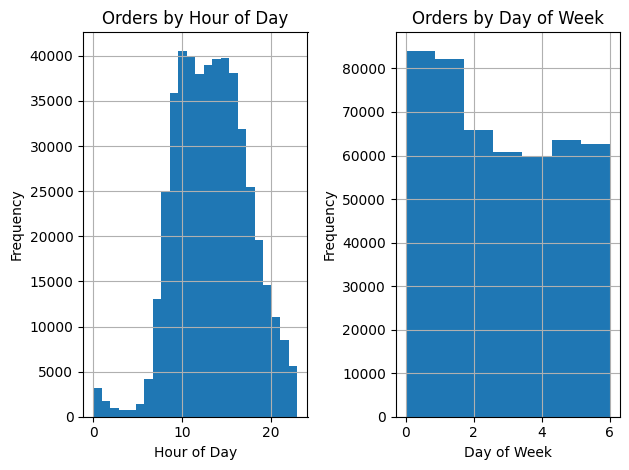

In [42]:
# Visualize data

plt.subplot(1, 2, 1)
orders['order_hour_of_day'].hist(bins=24, range=(0, 23))
plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
orders['order_dow'].hist(bins=7, range=(0,6))
plt.title('Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# Interpret data

The verification above shows that both 'order_hour_of_day' and 'order_dow' values are within sensible ranges. This confirms data integrity for these columns.

### [A2] What time of day do people shop for groceries?

In [43]:
# Group and aggregate data

order_counts_by_hour = orders['order_hour_of_day'].value_counts().sort_index()


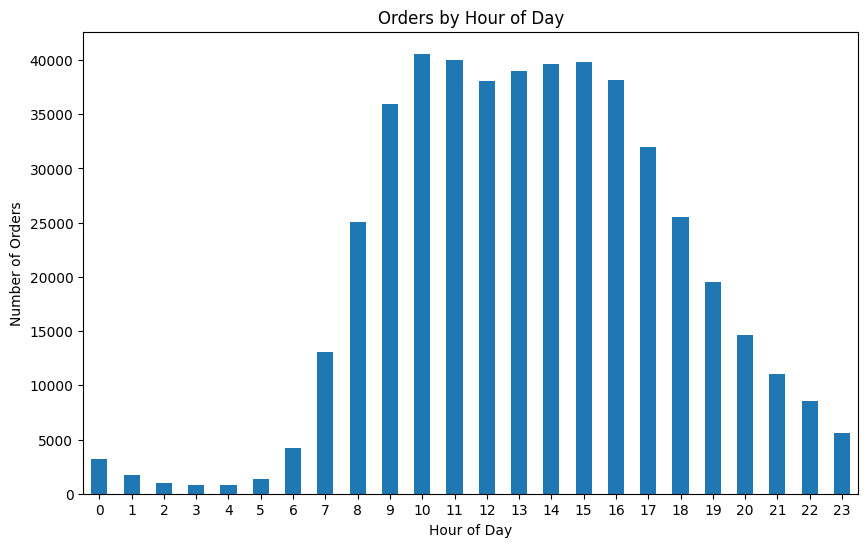

In [44]:
# Visualize data

plt.figure(figsize=(10, 6))

order_counts_by_hour.plot(kind='bar')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

# Interpret data

Based on the data visualized by the histogram above, there is a noticeable peak in orders between 10 AM and 4 PM. This suggests that most grocery shopping occurs during these hours, likely due to convenience during late morning and early afternoon.


<div class="alert alert-block alert-success"> <b>Reviewer's comment</b> <a 
class="tocSkip"></a>
Correct</div>

### [A3] What day of the week do people shop for groceries?

In [45]:
# Analyze data

order_counts_by_hour = orders['order_dow'].value_counts().sort_index()


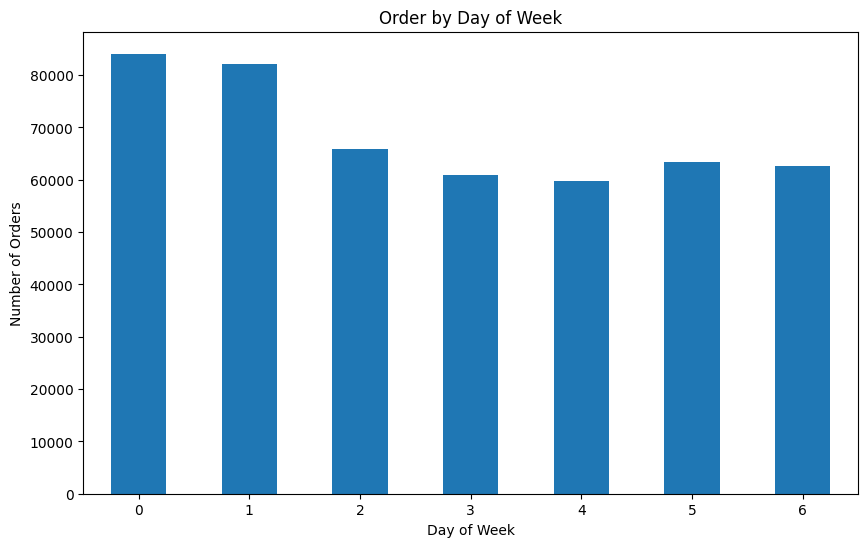

In [46]:
# Visualize data 

plt.figure(figsize=(10, 6))
order_counts_by_hour.plot(kind='bar')
plt.title('Order by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()


# Interpret data

Based on the data visualized by the bar chart above, There are peaks (in terms of high-activty shopping days) on days represented by 0 and 1, suggesting these are popular shopping days, possibly corresponding to weekends.


### [A4] How long do people wait until placing another order?

count    450148.000000
mean         11.101751
std           9.189975
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64


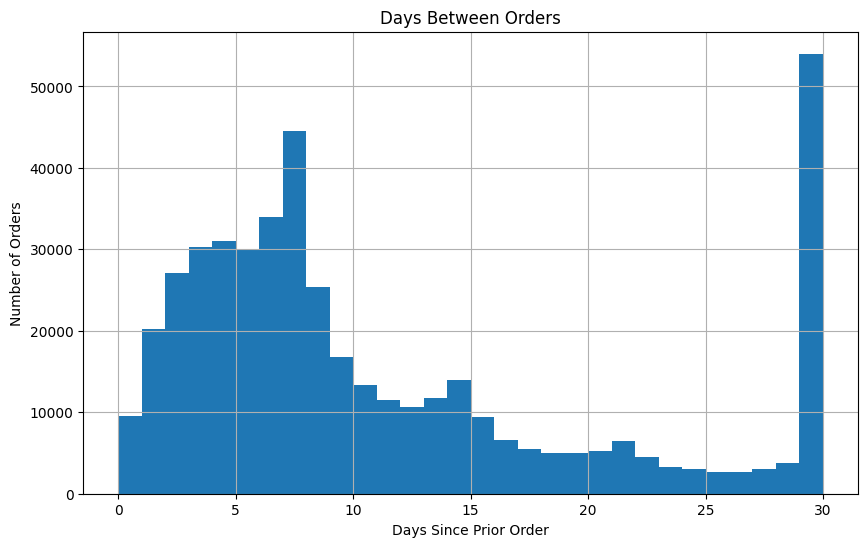

In [47]:
# Analyze data

wait_times = orders['days_since_prior_order']

print(wait_times.describe())


# Visualize data

plt.figure(figsize=(10, 6))
wait_times.hist(bins=30)
plt.title('Days Between Orders')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.show()


# Interpret data

As far as the data analysis goes: 

* People waits an average of 11.18 days before making another purchase.


As far as the bar (chart-based) data visualization goes:

* The distribution is right-skewed, which shows that most customers would remake their purchases within 1 to 10 days. 

#### [Must complete all to pass]

1. Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the histograms for both days on the same plot and describe the differences that you see.

2. Plot the distribution for the number of orders that customers place (e.g. how many customers placed only 1 order, how many placed only 2, how many only 3, and so on…)

3. What are the top 20 products that are ordered most frequently (display their id and name)?

# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the histograms for both days and describe the differences that you see.

In [48]:
# Filter the data

wednesday_orders = orders_df[orders_df['order_dow'] == 2]

saturday_orders = orders_df[orders_df['order_dow'] == 5]


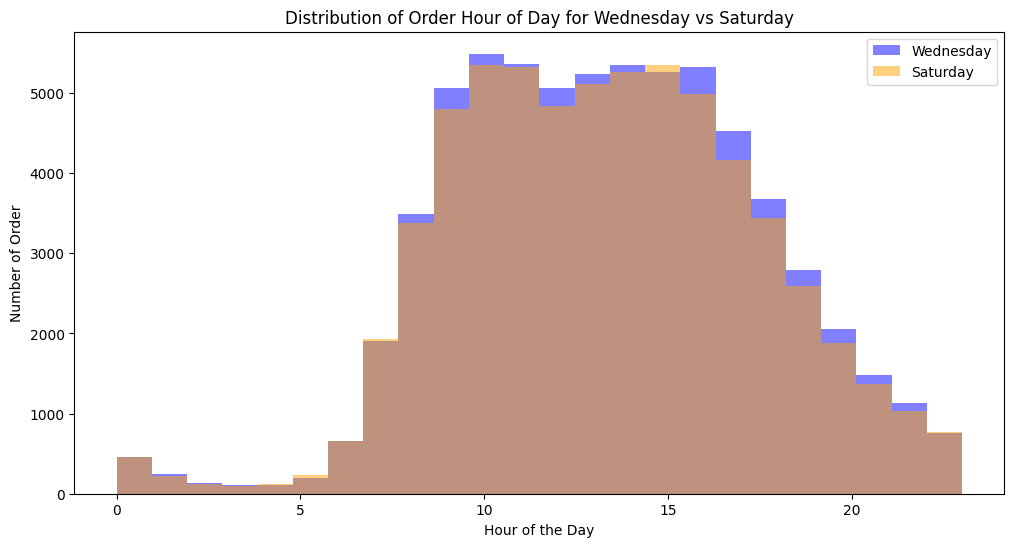

In [49]:
# Plot histograms

plt.figure(figsize=(12, 6))


## Plot for Wednesday

plt.hist(wednesday_orders['order_hour_of_day'], bins=24, alpha=0.5, label='Wednesday', color='blue')


## Plot for Saturday

plt.hist(saturday_orders['order_hour_of_day'], bins=24, alpha=0.5, label='Saturday', color='orange')

plt.xlabel('Hour of the Day')
plt.ylabel('Number of Order')
plt.title('Distribution of Order Hour of Day for Wednesday vs Saturday')
plt.legend()
plt.show()


# Interpret data

Based on the histogram's visualized data, both Wednesdays and Saturdays may have a peak during similar hours, likely indicating common busy times for ordering.

### [B2] What's the distribution for the number of orders per customer?

In [50]:
# Calculate orders per customer

orders_per_customer = orders_df.groupby('user_id')['order_id'].count()


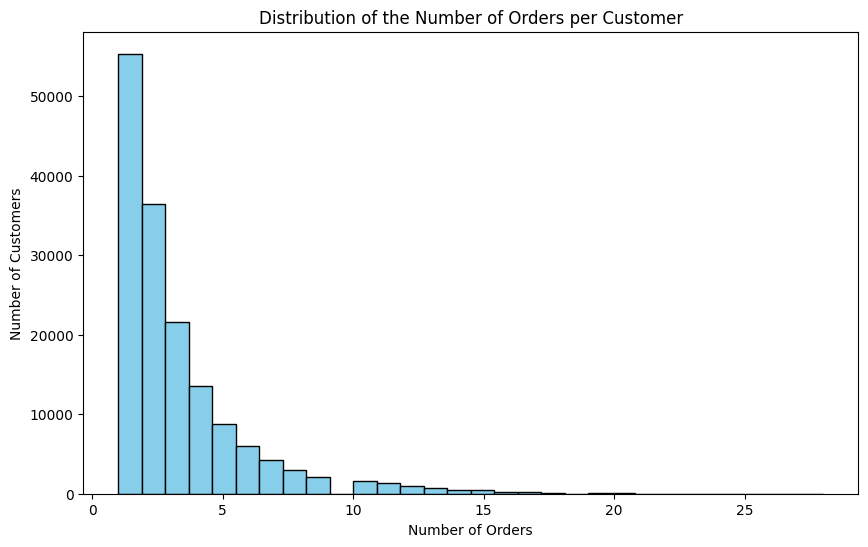

In [51]:
# Plot the distribution

plt.figure(figsize=(10, 6))
plt.hist(orders_per_customer, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.title('Distribution of the Number of Orders per Customer')
plt.show()

# Interpret data

Based on the histogram's data visualization, its right-skewness indicates that most customers have placed a relatively low number of orders.

### [B3] What are the top 20 popular products (display their id and name)?

In [52]:
# Calculate and merge

## Calculate product order frequencies

product_counts = order_products_df['product_id'].value_counts().head(20).reset_index()

product_counts.columns = ['product_id', 'count']

## Merge with product names

top_products = product_counts.merge(products_df[['product_id', 'product_name']], on='product_id', how='left')
    

In [53]:
# Sort and display result

print(top_products[['product_id', 'product_name', 'count']].sort_values(by='count', ascending=False))


    product_id              product_name  count
0        24852                    Banana  66050
1        13176    Bag of Organic Bananas  53297
2        21137      Organic Strawberries  37039
3        21903      Organic Baby Spinach  33971
4        47209      Organic Hass Avocado  29773
5        47766           Organic Avocado  24689
6        47626               Large Lemon  21495
7        16797              Strawberries  20018
8        26209                     Limes  19690
9        27845        Organic Whole Milk  19600
10       27966       Organic Raspberries  19197
11       22935      Organic Yellow Onion  15898
12       24964            Organic Garlic  15292
13       45007          Organic Zucchini  14584
14       39275       Organic Blueberries  13879
15       49683            Cucumber Kirby  13675
16       28204        Organic Fuji Apple  12544
17        5876             Organic Lemon  12232
18        8277  Apple Honeycrisp Organic  11993
19       40706    Organic Grape Tomatoes

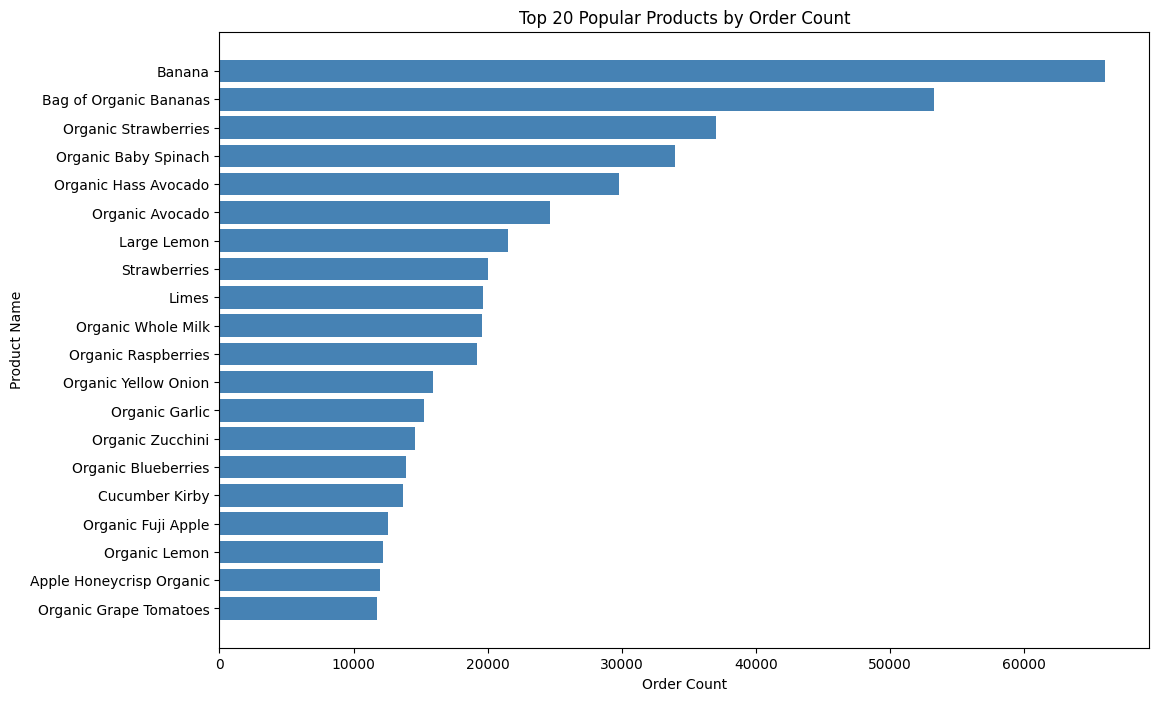

In [54]:
# Visualize the result data in a bar chart

top_20_products_sorted = top_products.sort_values(by='count', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(top_20_products_sorted['product_name'], top_20_products_sorted['count'], color='steelblue')

plt.xlabel('Order Count')
plt.ylabel('Product Name')
plt.title('Top 20 Popular Products by Order Count')
plt.gca().invert_yaxis()
plt.show()
         


# Interpret data

The bar chart above displays the top 20 popular products, with each labeled by its ID and name. 


#### [Must complete at least two to pass]

1. How many items do people typically buy in one order? What does the distribution look like?

2. What are the top 20 items that are reordered most frequently (display their names and product IDs)?

3. For each product, what proportion of its orders are reorders (create a table with columns for the product ID, product name, and reorder proportion)?

4. For each customer, what proportion of their products ordered are reorders?

5. What are the top 20 items that people put in their carts first (display the product IDs, product names, and number of times they were the first item added to the cart)?

# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?

In [55]:
# Group data by 'order_id' and count the number of items per order

items_per_order = order_products_df.groupby('order_id').size()


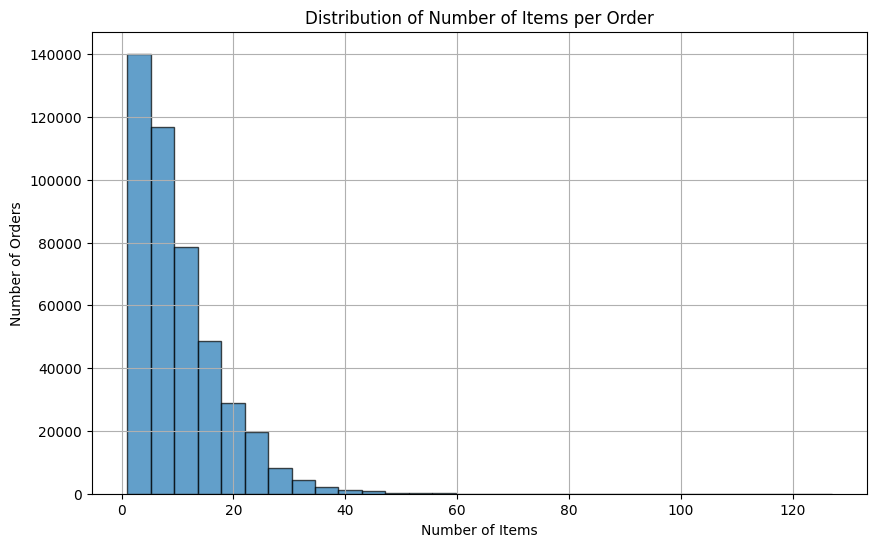

In [56]:
# Plot the distribution

plt.figure(figsize=(10, 6))
plt.hist(items_per_order, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Number of Items per Order')
plt.xlabel('Number of Items')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()


In [57]:
# Calculate summary statistics

mean_items = items_per_order.mean()

median_items = items_per_order.median()

print(f"Average number of items per order: {mean_items}")

print(f"Median number of items per order: {median_items}")


Average number of items per order: 10.098983215049127
Median number of items per order: 8.0


# Interpret data

Based om the histogram's left-skewed shape above, the distribution shows that most orders contain a moderate number of items, with fewer orders having a very high or very low item count.


### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

In [58]:
# Filter for reordered items and count occurrences

reordered_items = order_products_df[order_products_df['reordered'] == 1]

reordered_counts = reordered_items.groupby('product_id').size()


In [59]:
# Sort and get top 20 items reordered

top_20_items_reordered = reordered_counts.nlargest(20).reset_index(name='count')


In [60]:
# Merge with product names

top_20_items_reordered = top_20_items_reordered.merge(products_df, on='product_id') [['product_id', 'product_name', 'count']]

In [61]:
# Drop duplcate rows by 'product_id' and 'product_name'

unique_reorders = top_20_items_reordered.drop_duplicates(subset=['product_id', 'product_name'])

In [62]:
# Display the results

print(unique_reorders)


    product_id              product_name  count
0        24852                    Banana  55763
1        13176    Bag of Organic Bananas  44450
2        21137      Organic Strawberries  28639
3        21903      Organic Baby Spinach  26233
4        47209      Organic Hass Avocado  23629
5        47766           Organic Avocado  18743
6        27845        Organic Whole Milk  16251
7        47626               Large Lemon  15044
8        27966       Organic Raspberries  14748
9        16797              Strawberries  13945
10       26209                     Limes  13327
11       22935      Organic Yellow Onion  11145
12       24964            Organic Garlic  10411
13       45007          Organic Zucchini  10076
14       49683            Cucumber Kirby   9538
15       28204        Organic Fuji Apple   8989
16        8277  Apple Honeycrisp Organic   8836
17       39275       Organic Blueberries   8799
18        5876             Organic Lemon   8412
19       49235       Organic Half & Half

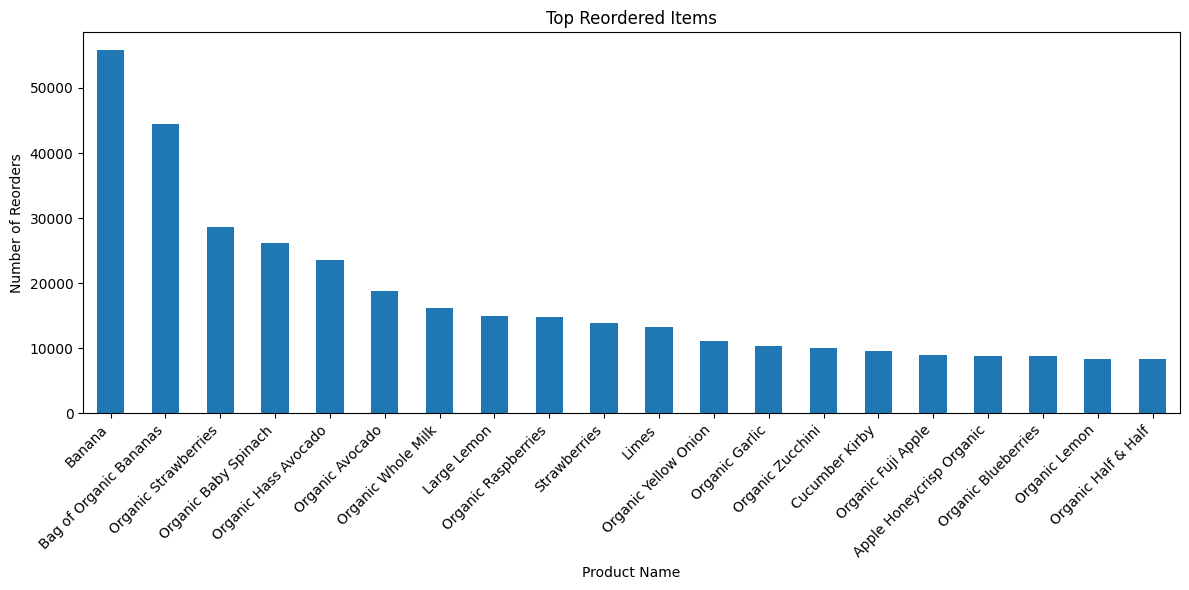

In [63]:
# Visualize result data in a bar plot

unique_reorders.plot(kind='bar', x='product_name', y='count', legend=False, figsize=(12, 6))

plt.title('Top Reordered Items')
plt.xlabel('Product Name')
plt.ylabel('Number of Reorders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Interpret data

The bar plot above displays the top 20 items reordered most frequently by customers, with each one labeled by its ID and name.

### [C3] For each product, what proportion of its orders are reorders?

### [C4] For each customer, what proportion of their products ordered are reorders?

### [C5] What are the top 20 items that people put in their carts first? 

# Conclusion

In this analysis of Instacart's dataset, we explored customer ordering patterns and product popularity. Key findings include:

* <b>Order Patterns:</b> Customers tend to place a few orders more frequently, with a significant drop-off in higher order counts. This suggests a regular but moderate level of shopping among the majority of users.


* <b>Product Popularity:</b> The most popular products are predominantly fresh produce, such as bananas and organic options, indicating a preference for health-conscious grocery items.


* <b>Key Shopping Times:</b> Order activity peaks mid-day, highlighting optimal times for customer engagement and promotions.


These insights can guide Instacart in optimizing their inventory management and marketing strategies to better serve customer needs and enhance their shopping experience.
